# Pre-Processing

In [33]:
import tensorflow as tf
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
# Data paths
base_path = ('../data/chest_xray')

train_path = base_path / "train"
val_path   = base_path / "val"
test_path  = base_path / "test"

In [35]:
# Constantes
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

## Conversão imagens

In [ ]:
def create_dataset(path, img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=False, shuffle=True):
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='categorical',
        shuffle=shuffle
    )

    # Normalização
    ds = ds.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))
    
    # Data augmentation
    if augment:
        data_aug = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.1),
            tf.keras.layers.RandomZoom(0.1)
        ])
        ds = ds.map(lambda x, y: (data_aug(x, training=True), y))
    return ds


In [ ]:
train_ds = create_dataset(train_path, augment=True, shuffle = True)
val_ds   = create_dataset(val_path, augment=False, shuffle=False)
test_ds  = create_dataset(test_path, augment=False, shuffle=False)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


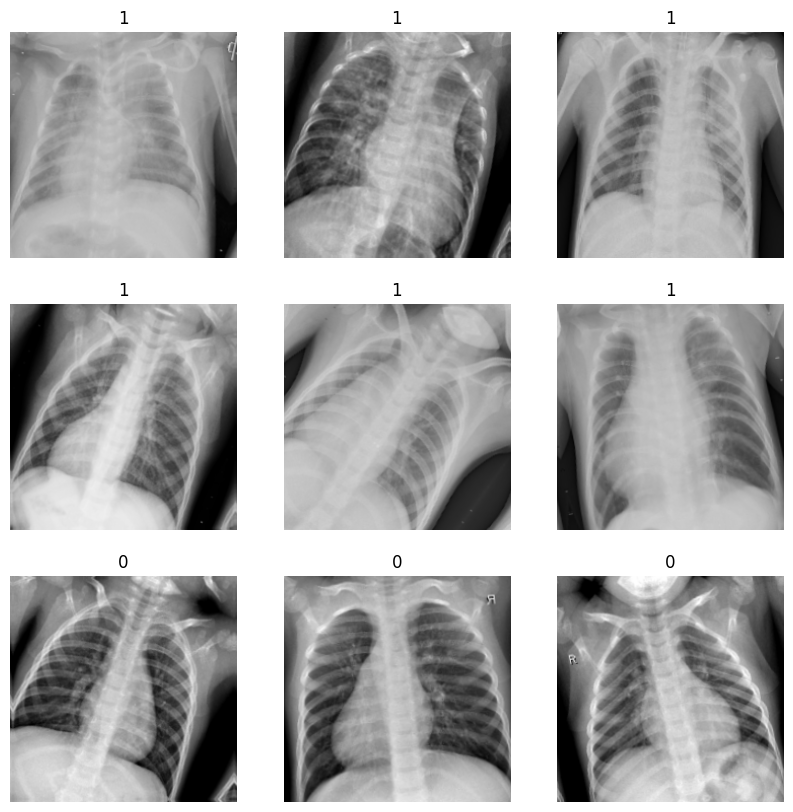

In [38]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(tf.argmax(labels[i]).numpy())
        plt.axis("off")
plt.show()
